First 5 Rows:
   V1            V2       V3         V4  V5    V6   V7   V8       V9  V10  \
0  58    management  married   tertiary  no  2143  yes   no  unknown    5   
1  44    technician   single  secondary  no    29  yes   no  unknown    5   
2  33  entrepreneur  married  secondary  no     2  yes  yes  unknown    5   
3  47   blue-collar  married    unknown  no  1506  yes   no  unknown    5   
4  33       unknown   single    unknown  no     1   no   no  unknown    5   

   V11  V12  V13  V14  V15      V16 Class  
0  may  261    1   -1    0  unknown     1  
1  may  151    1   -1    0  unknown     1  
2  may   76    1   -1    0  unknown     1  
3  may   92    1   -1    0  unknown     1  
4  may  198    1   -1    0  unknown     1  

Accuracy Score:
0.8740462235983634

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      7952
           1       0.48      0.48      0.48      1091

    accuracy                       

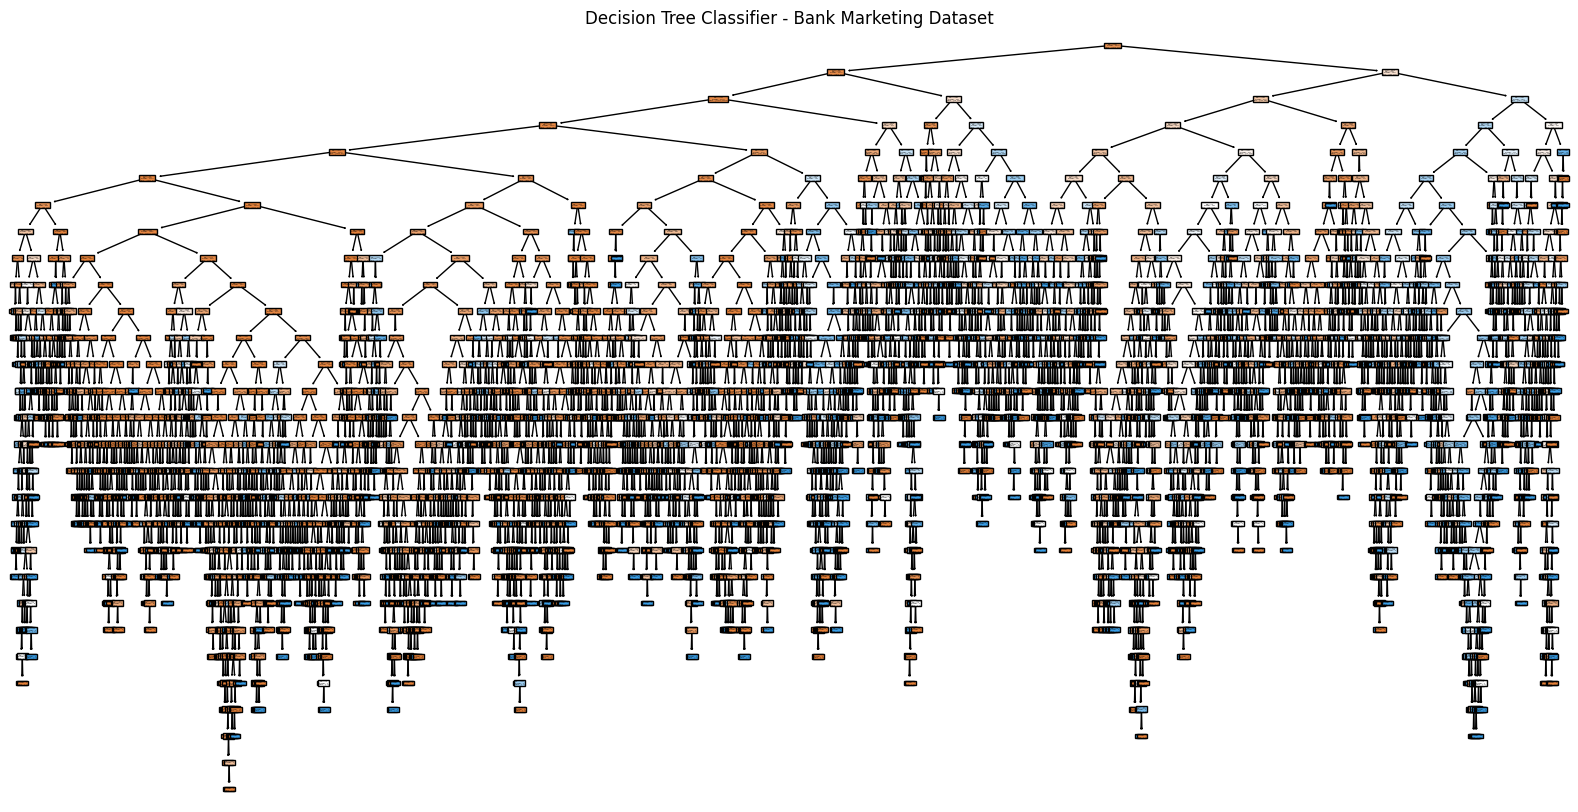

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn import tree

# Load Bank Marketing Dataset
bank = fetch_openml(name='bank-marketing', version=1, as_frame=True)

# Create dataframe
df = bank.frame

# Show first 5 rows
print("First 5 Rows:")
print(df.head())

# Convert categorical columns into numerical
for col in df.columns:
    if df[col].dtype == 'object' or str(df[col].dtype) == 'category':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))

# Select target column automatically
target_column = df.columns[-1]

# Features and target
X = df.drop(columns=[target_column])
y = df[target_column]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create Decision Tree model
model = DecisionTreeClassifier(random_state=42)

# Train model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Accuracy Score
print("\nAccuracy Score:")
print(accuracy_score(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot Decision Tree
plt.figure(figsize=(20,10))

tree.plot_tree(
    model,
    filled=True,
    feature_names=X.columns
)

plt.title("Decision Tree Classifier - Bank Marketing Dataset")

plt.show()